# PowerCo — Exploratory Data Analysis

**Goal of this notebook:** get familiar with the three datasets PowerCo has provided before we
move on to modeling customer churn. Specifically we will look at:

1. The **data types** of each column, and whether they match what the column is supposed to represent
2. **Descriptive statistics** (counts, uniques, min/max, mean, etc.) to understand how values vary
3. **Distributions** of the key columns, visualized simply and appropriately for the data type

We have two raw files:
- `client_data.csv` — customer info: consumption, contract dates, forecasts, margins, and whether the client churned
- `price_data.csv` — historical variable/fixed energy prices per client per month


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

%matplotlib inline


In [2]:
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

print("client_data shape:", client_df.shape)
print("price_data shape:", price_df.shape)


client_data shape: (14606, 26)
price_data shape: (193002, 8)


## 1. Data types

We start by checking the dtype pandas inferred for each column, and cross-checking it against the
data description PowerCo sent over. A few things to look out for:
- Date columns (`date_activ`, `date_end`, `date_modif_prod`, `date_renewal`, `price_date`) are read in
  as plain strings/objects — we'll need to convert these to `datetime` for any time-based analysis
- `churn` and `has_gas` are really categorical/binary flags, even though `churn` looks numeric
- Hashed columns like `channel_sales` and `origin_up` are categorical codes, not free text


In [3]:
client_df.dtypes

id                                    str
channel_sales                         str
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                            str
date_end                              str
date_modif_prod                       str
date_renewal                          str
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                               str
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up                         

In [4]:
price_df.dtypes

id                        str
price_date                str
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

### 1.1 Fixing date columns

Convert the date-like string columns to proper `datetime` dtype so pandas understands them as dates.

In [5]:
client_date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in client_date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

price_df['price_date'] = pd.to_datetime(price_df['price_date'])

client_df[client_date_cols].dtypes


date_activ         datetime64[us]
date_end           datetime64[us]
date_modif_prod    datetime64[us]
date_renewal       datetime64[us]
dtype: object

### 1.2 Quick look at the data itself

In [6]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [7]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## 2. Descriptive statistics

Now that types are cleaned up, let's look at how values vary within each column. This includes:
- How many missing values there are
- How many unique values there are per column (useful to spot near-constant or ID-like columns)
- Standard descriptive stats (mean, std, min, max, quartiles) for numeric columns
- Value counts for the key categorical columns


### 2.1 Missing values

In [8]:
print("Missing values — client_data:")
print(client_df.isnull().sum()[client_df.isnull().sum() > 0])
print("\nMissing values — price_data:")
print(price_df.isnull().sum()[price_df.isnull().sum() > 0])


Missing values — client_data:
Series([], dtype: int64)

Missing values — price_data:
Series([], dtype: int64)


### 2.2 Unique value counts per column

This tells us, at a glance, which columns are effectively constant, which are IDs, and which are genuinely categorical.

In [9]:
pd.DataFrame({
    'dtype': client_df.dtypes,
    'n_unique': client_df.nunique(),
    'n_missing': client_df.isnull().sum()
}).sort_values('n_unique')


,dtype,n_unique,n_missing
churn,int64,2,0
has_gas,str,2,0
origin_up,str,6,0
channel_sales,str,8,0
nb_prod_act,int64,10,0
forecast_discount_energy,float64,12,0
num_years_antig,int64,13,0
forecast_price_pow_off_peak,float64,41,0
forecast_price_energy_peak,float64,329,0
date_end,datetime64[us],368,0


### 2.3 Descriptive statistics — numeric columns (client_data)

In [10]:
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


### 2.4 Descriptive statistics — categorical columns (client_data)

In [11]:
categorical_cols = ['channel_sales', 'has_gas', 'origin_up']
for col in categorical_cols:
    print(f"--- {col} ---")
    print(client_df[col].value_counts())
    print()


--- channel_sales ---
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

--- has_gas ---
has_gas
f    11955
t     2651
Name: count, dtype: int64

--- origin_up ---
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64



**Observations so far:**
- `channel_sales` and `origin_up` are hashed sales-channel / campaign codes — a handful of values dominate,
  and `channel_sales` even has a `MISSING` category baked in as a string rather than a true null
- `has_gas` is a simple `t`/`f` flag for whether the client also buys gas from PowerCo
- `churn` is our target: about **9.7%** of clients churned, so this is an imbalanced classification problem
- Several numeric columns (`cons_12m`, `cons_gas_12m`, `imp_cons`, `net_margin`) have very large maximums
  relative to their median — a sign of strong right-skew / outliers we should visualize


### 2.5 Descriptive statistics — price_data

In [12]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


## 3. Distributions

With the statistics above as a guide, we now visualize the columns. A couple of principles we'll
follow (per PowerCo's hints):

- **Categorical columns with few categories** → bar chart of counts
- **Categorical columns with many unique values** (e.g. `id`) → not plotted, a chart would be meaningless
- **Numeric columns** → histogram / distribution plot; where a column is heavily right-skewed (lots of
  clients near zero and a few very large values) we log-transform before plotting so the shape is visible


### 3.1 Churn — our target variable

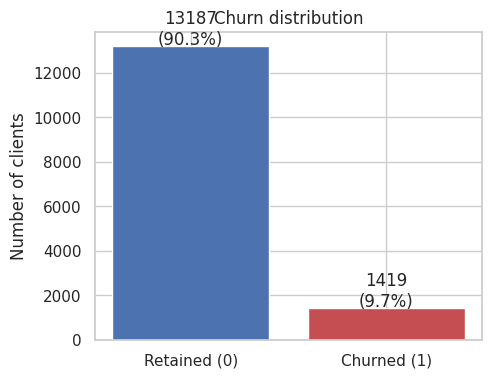

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = client_df['churn'].value_counts().sort_index()
ax.bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 100, f"{v}\n({v/len(client_df)*100:.1f}%)", ha='center')
ax.set_ylabel('Number of clients')
ax.set_title('Churn distribution')
plt.show()


### 3.2 Key categorical columns

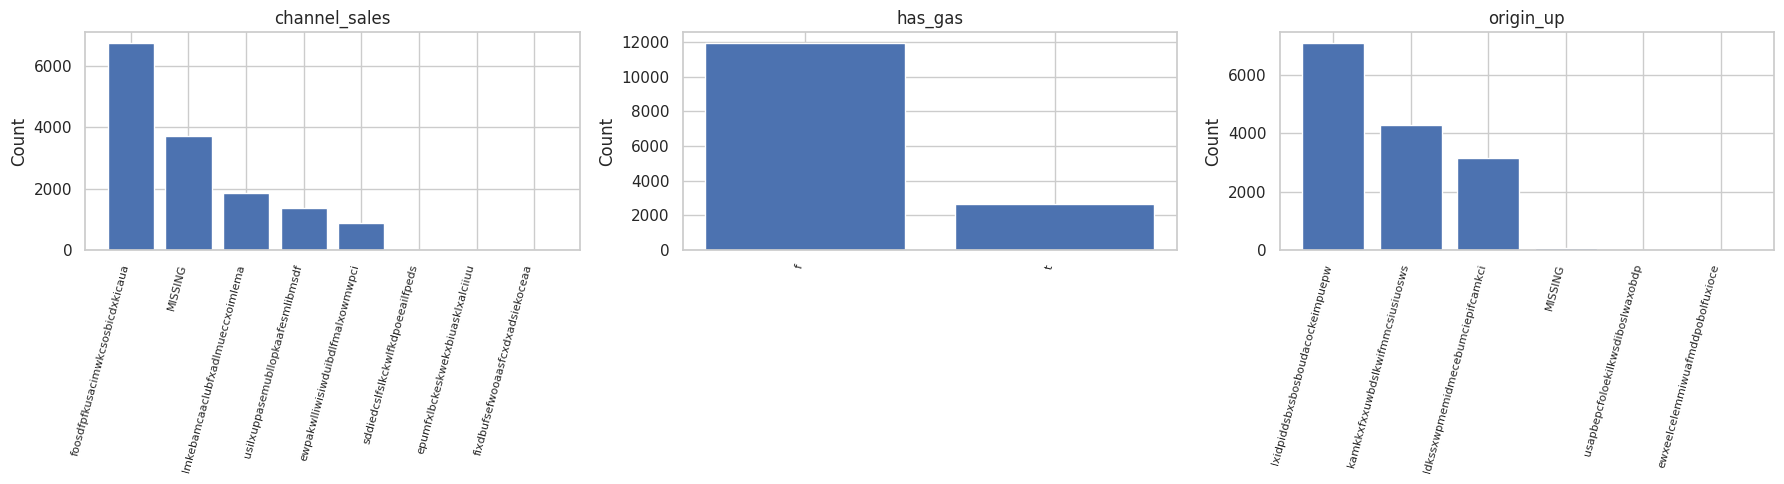

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['channel_sales', 'has_gas', 'origin_up']):
    counts = client_df[col].value_counts()
    ax.bar(range(len(counts)), counts.values, color='#4C72B0')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=75, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.3 Consumption & forecast columns

These columns are strongly right-skewed (a small number of very large industrial consumers alongside
many small ones), so we plot them on a log scale (adding 1 before logging, since many values are 0).


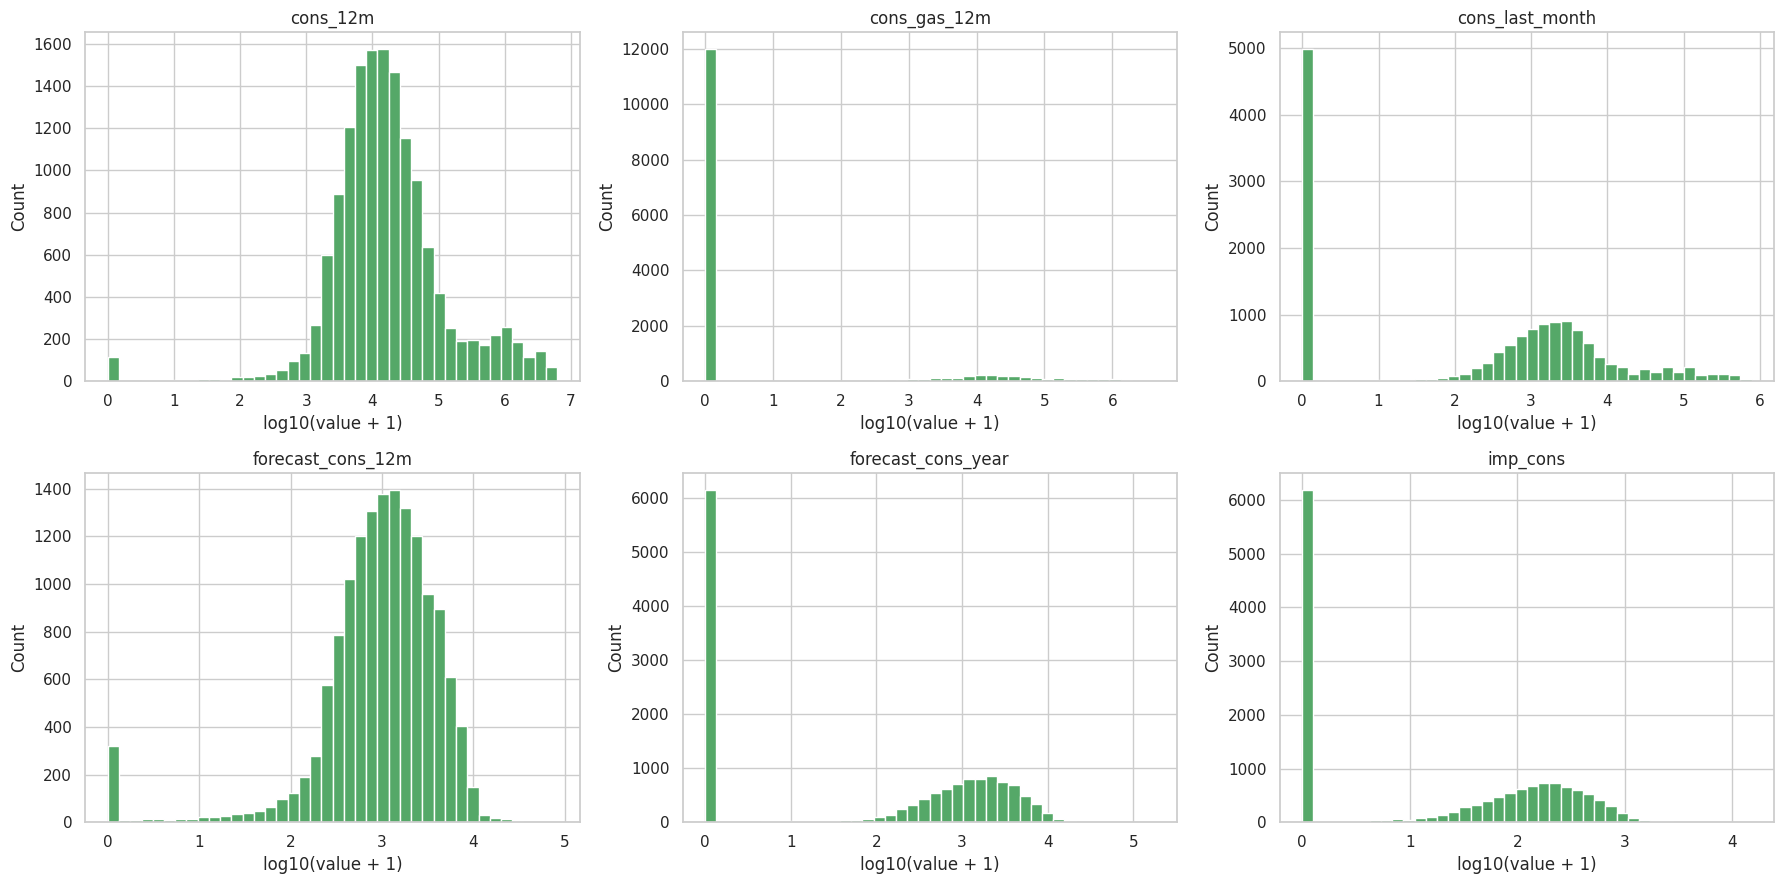

In [15]:
cons_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month',
             'forecast_cons_12m', 'forecast_cons_year', 'imp_cons']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, cons_cols):
    vals = np.log10(client_df[col].clip(lower=0) + 1)
    ax.hist(vals, bins=40, color='#55A868', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('log10(value + 1)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.4 Margins, contract size & tenure

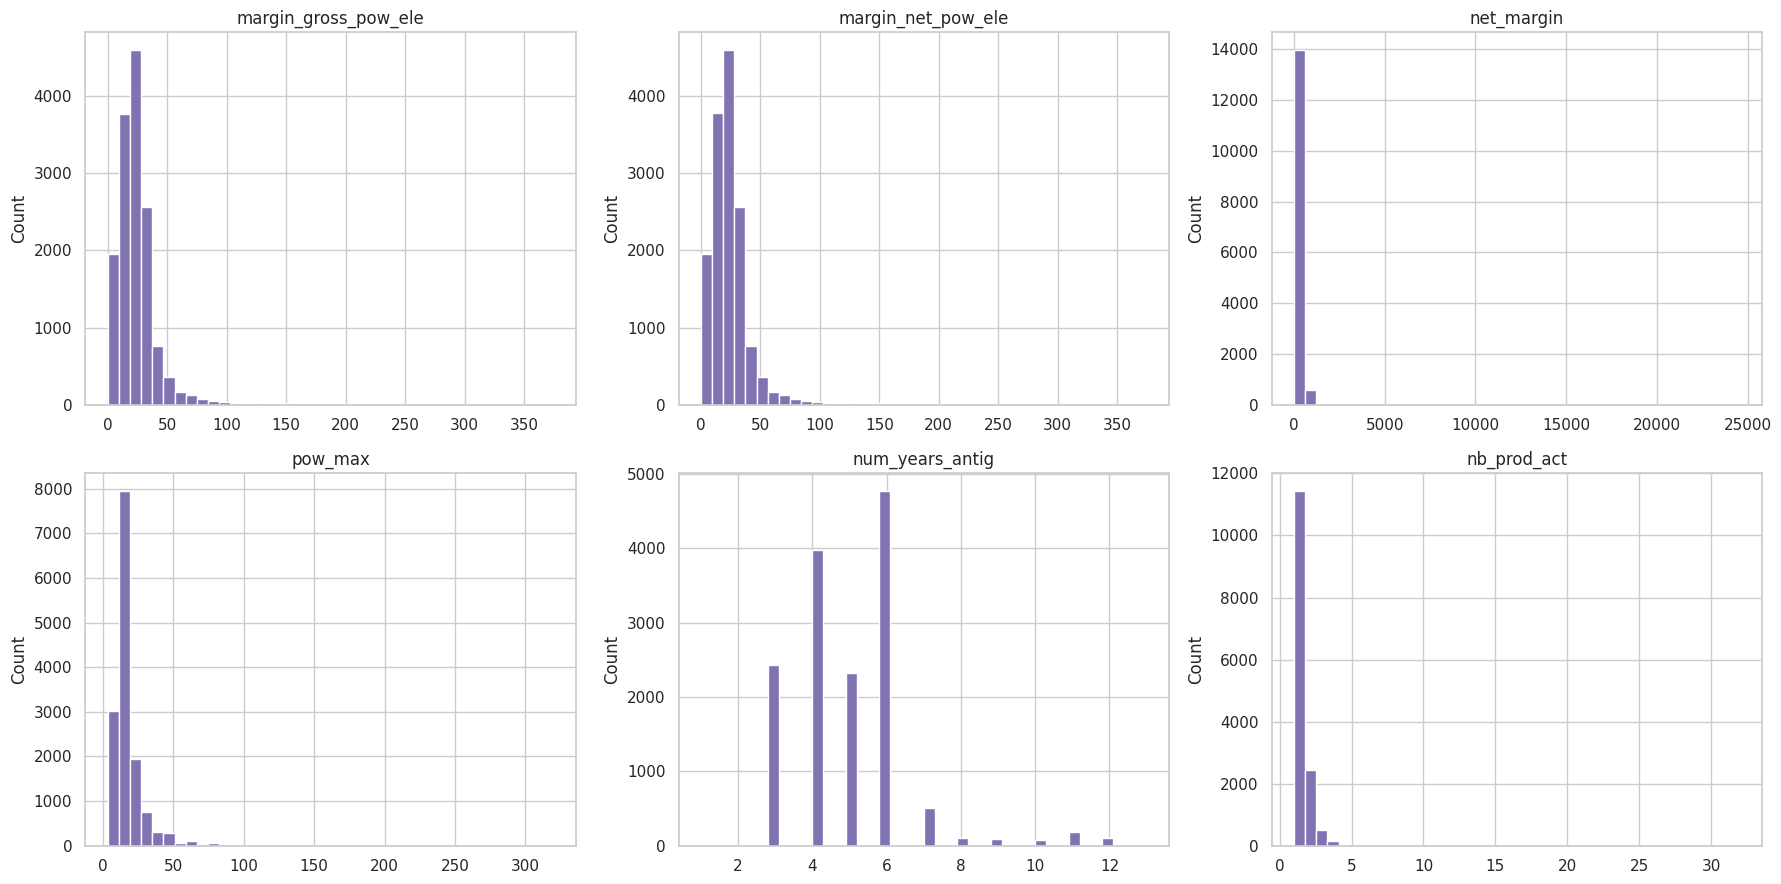

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

plot_cols = ['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin',
             'pow_max', 'num_years_antig', 'nb_prod_act']

for ax, col in zip(axes, plot_cols):
    ax.hist(client_df[col], bins=40, color='#8172B2', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.5 Forecasted / off-peak prices (client_data)

These come out of PowerCo's forecasting model and are naturally bounded, so a plain (non-log) histogram
works fine here.


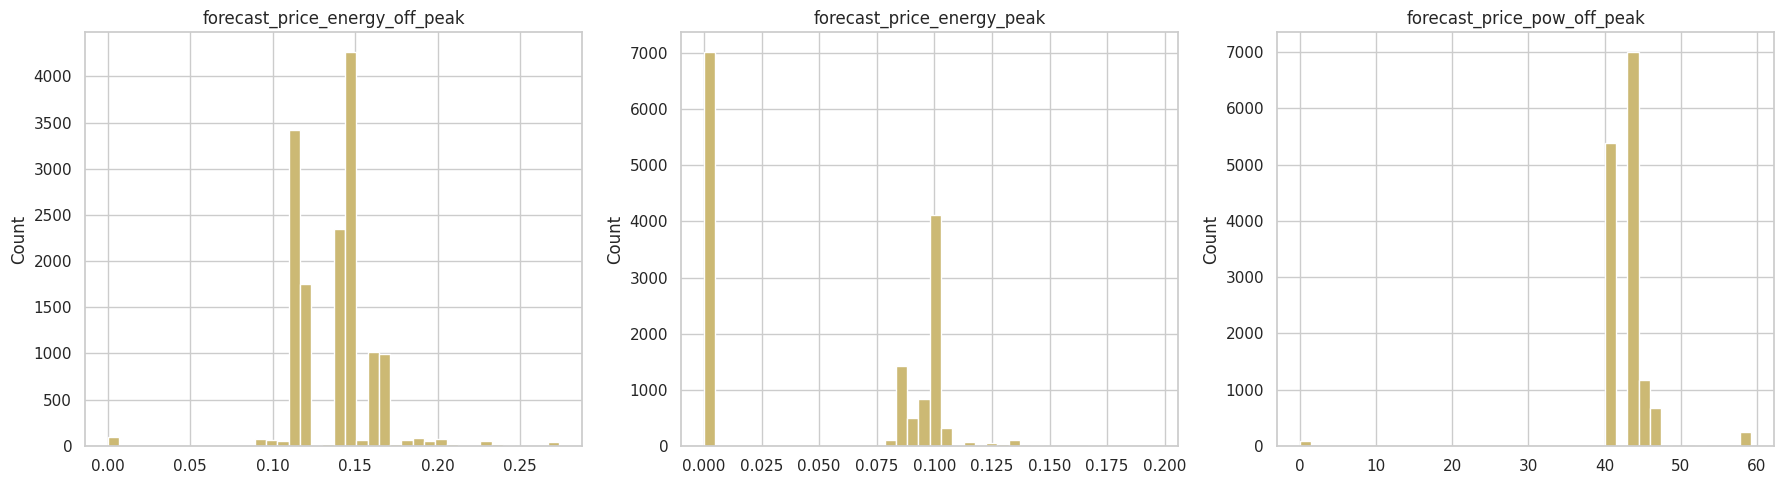

In [17]:
price_cols = ['forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, price_cols):
    ax.hist(client_df[col], bins=40, color='#CCB974', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.6 Historical prices (price_data.csv)

`price_data` holds monthly off-peak / peak / mid-peak variable and fixed prices per client. Many
clients only use the off-peak tariff, so `price_peak_var`, `price_mid_peak_var`, `price_peak_fix` and
`price_mid_peak_fix` are 0 for a large share of rows — that's expected, not missing data.


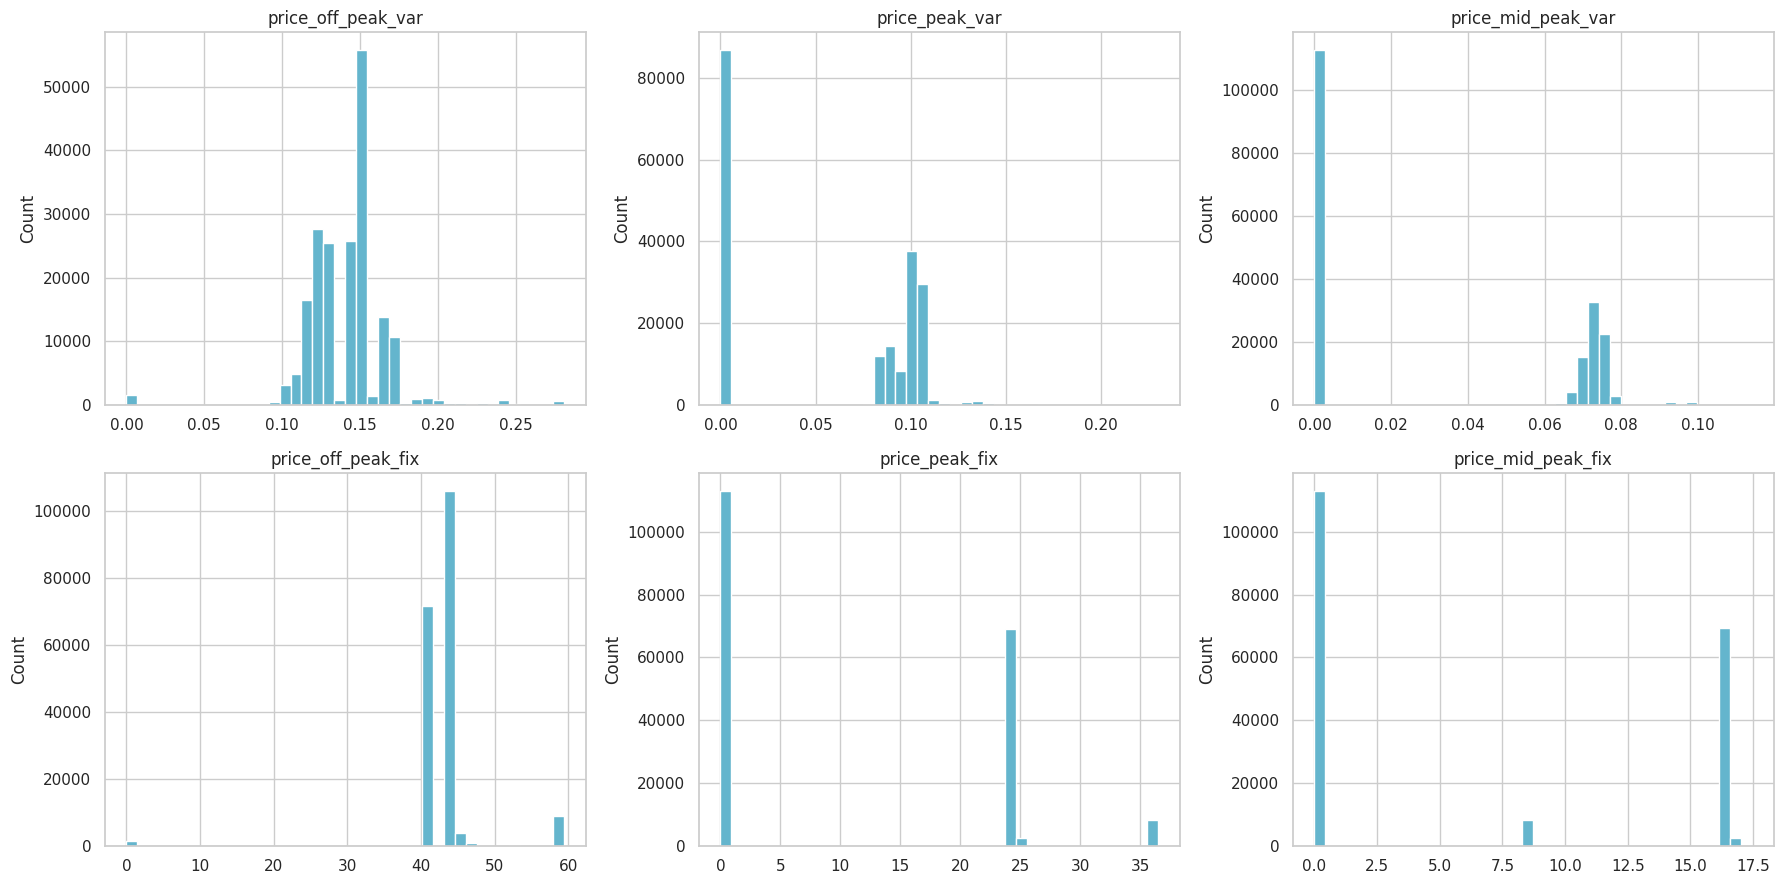

In [18]:
price_plot_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
                    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, price_plot_cols):
    ax.hist(price_df[col], bins=40, color='#64B5CD', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.7 Contract dates over time

A quick look at when contracts were activated, last modified, and are due to renew — useful for
spotting seasonality or data-entry artifacts (e.g. a suspicious spike on one exact date).


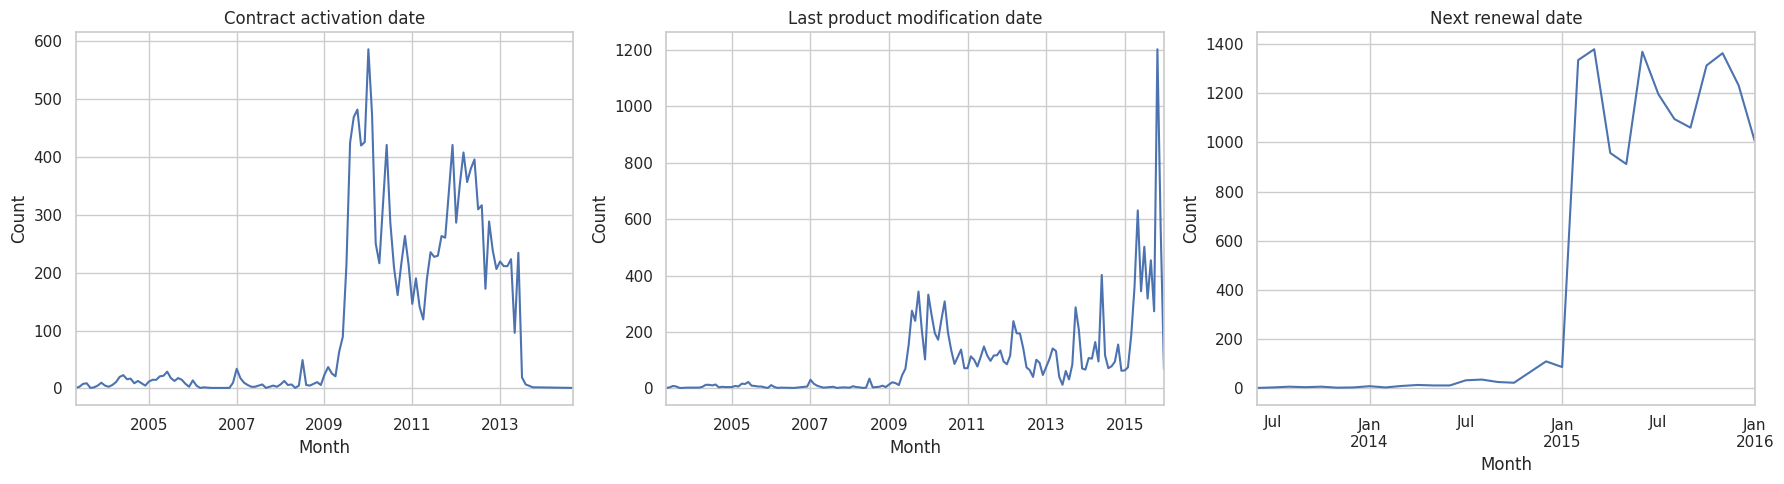

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['date_activ', 'date_modif_prod', 'date_renewal'],
    ['Contract activation date', 'Last product modification date', 'Next renewal date']
):
    client_df[col].dt.to_period('M').value_counts().sort_index().plot(ax=ax, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 4. Relationship between churn and the independent variables

Now that we understand each column on its own, the natural next question is: **which variables
actually look different between clients who churned and clients who stayed?** This gives us an early
read on what might be predictive before we build a model.

We'll look at this two ways:
- **Categorical variables** → churn *rate* within each category (not raw counts, since category sizes differ a lot)
- **Numeric variables** → distribution of the variable split by churn (0 vs 1), plus a simple correlation check


### 4.1 Churn rate by categorical variable

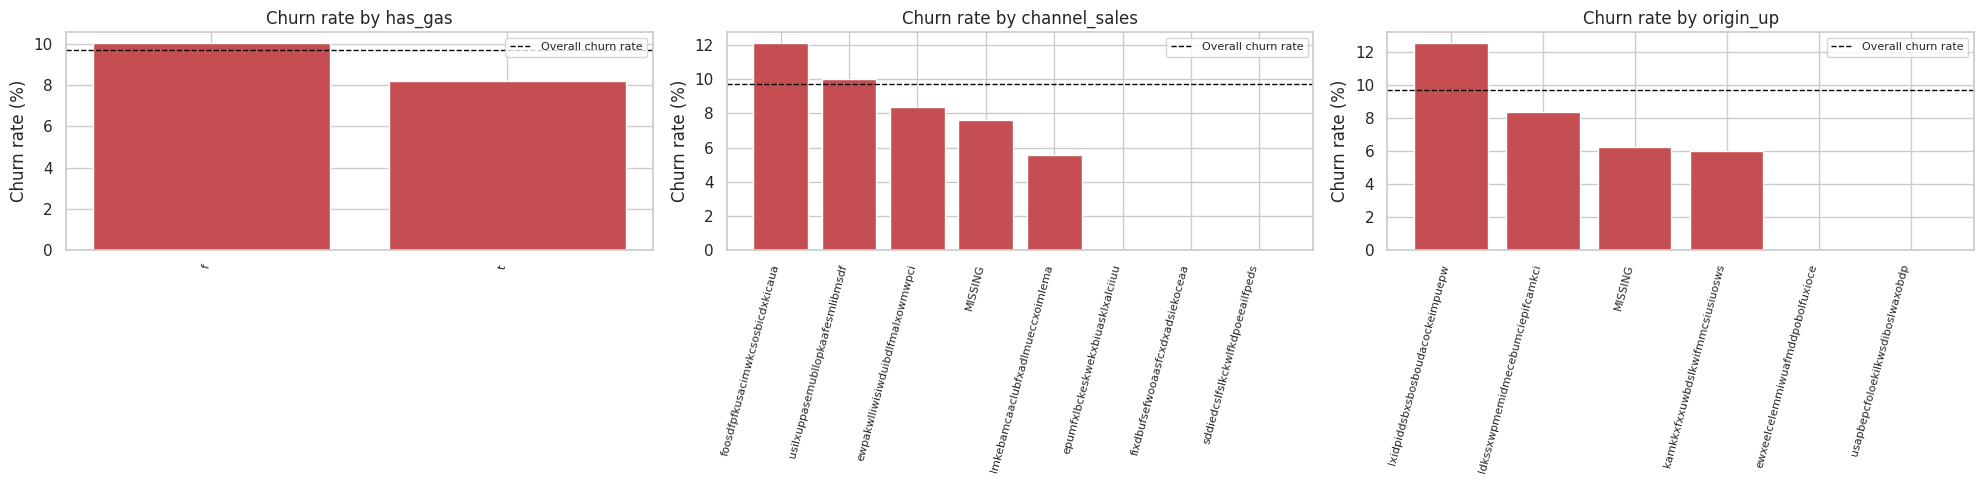

In [20]:
cat_cols_for_churn = ['has_gas', 'channel_sales', 'origin_up']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, cat_cols_for_churn):
    churn_rate = client_df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    ax.bar(range(len(churn_rate)), churn_rate.values, color='#C44E52')
    ax.axhline(client_df['churn'].mean() * 100, color='black', linestyle='--', linewidth=1,
               label='Overall churn rate')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=75, ha='right', fontsize=8)
    ax.set_ylabel('Churn rate (%)')
    ax.set_title(f'Churn rate by {col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 4.2 Churn rate by number of active products

`nb_prod_act` has a long tail of rare values (5+ products), so we group anything above 3 into a
single "4+" bucket to keep the chart readable.


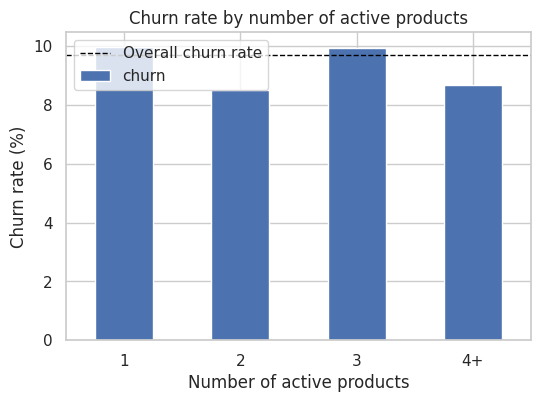

In [21]:
nb_prod_grouped = client_df['nb_prod_act'].clip(upper=4).replace({4: '4+'}).astype(str)
churn_by_nb_prod = client_df.assign(nb_prod_grouped=nb_prod_grouped).groupby('nb_prod_grouped')['churn'].mean() * 100
order = ['1', '2', '3', '4+']
churn_by_nb_prod = churn_by_nb_prod.reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_nb_prod.plot(kind='bar', ax=ax, color='#4C72B0')
ax.axhline(client_df['churn'].mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall churn rate')
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Number of active products')
ax.set_title('Churn rate by number of active products')
ax.legend()
plt.xticks(rotation=0)
plt.show()


 

For each numeric variable we compare the distribution for retained (0) vs churned (1) clients using
boxplots. Heavily skewed consumption/margin columns are log-transformed first so the boxes are readable.


/tmp/ipykernel_158/1418181986.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='churn', y=f'log_{col}', ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_158/1418181986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_158/1418181986.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='churn', y=f'log_{col}', ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_158/1418181986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

/tmp/ipykernel_158/1418181986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])


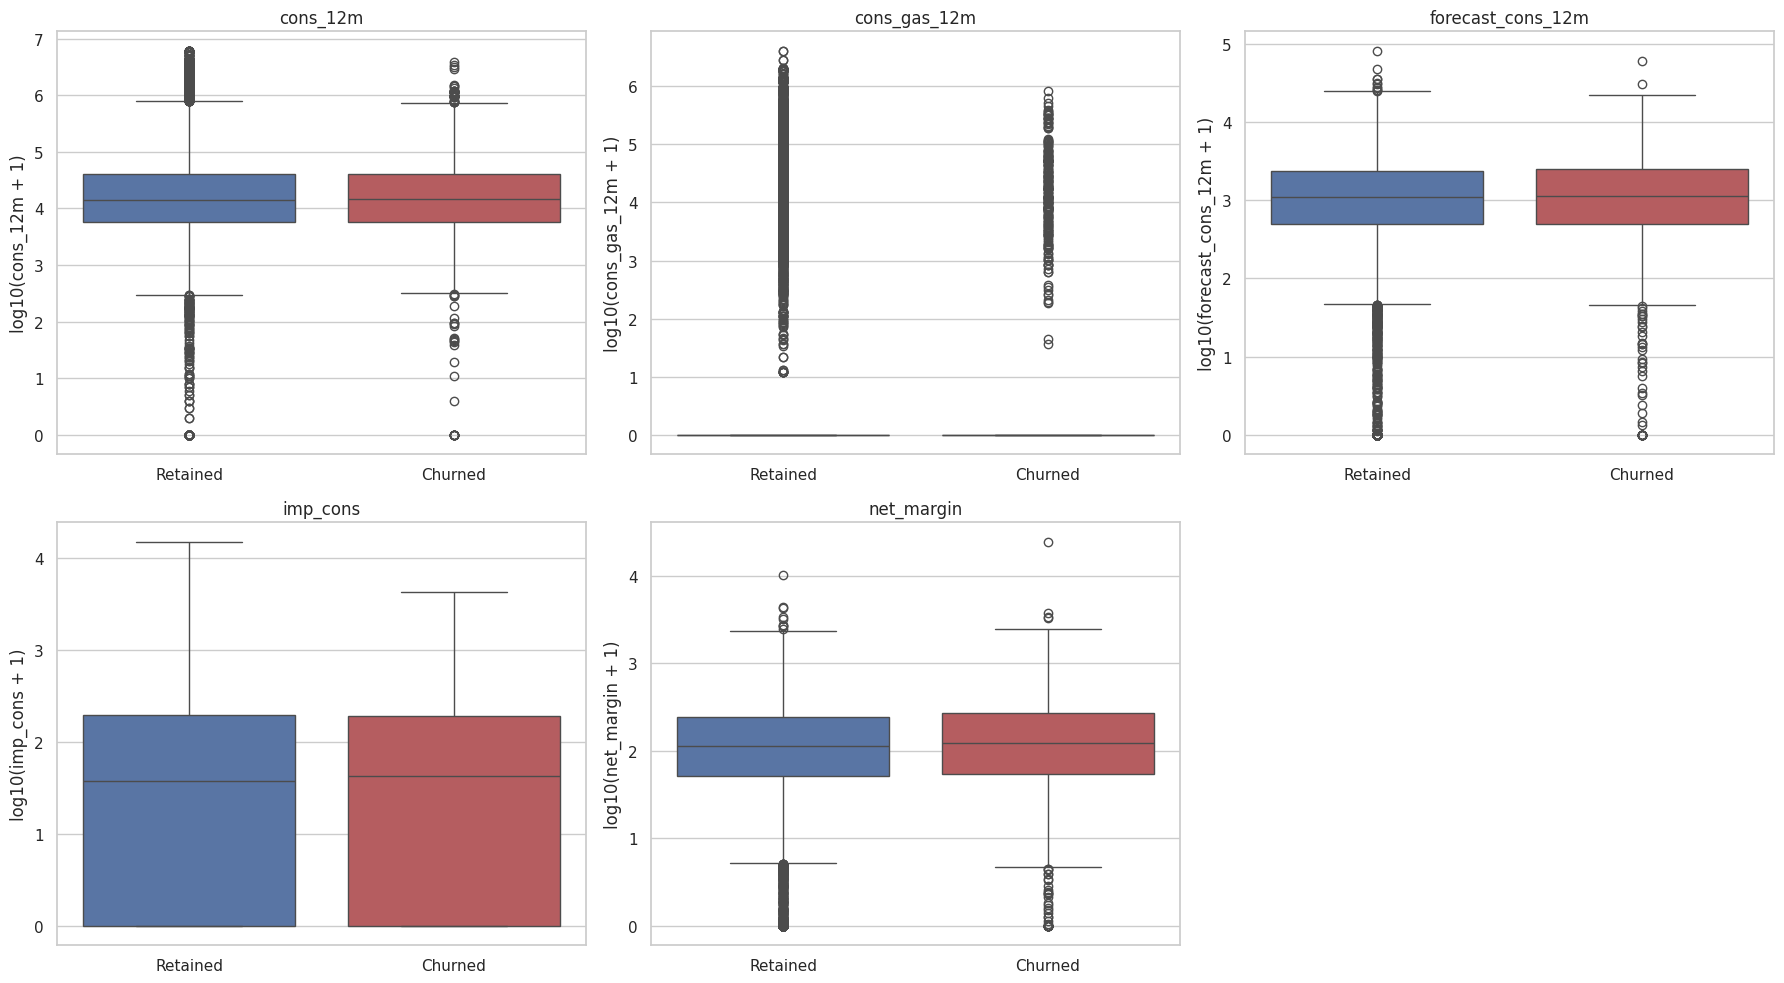

In [22]:
numeric_vs_churn_log = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m', 'imp_cons', 'net_margin']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vs_churn_log):
    plot_df = client_df.copy()
    plot_df[f'log_{col}'] = np.log10(plot_df[col].clip(lower=0) + 1)
    sns.boxplot(data=plot_df, x='churn', y=f'log_{col}', ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(col)
    ax.set_ylabel(f'log10({col} + 1)')
    ax.set_xlabel('')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


/tmp/ipykernel_158/1582042456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=client_df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_158/1582042456.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_158/1582042456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=client_df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_158/1582042456.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtick

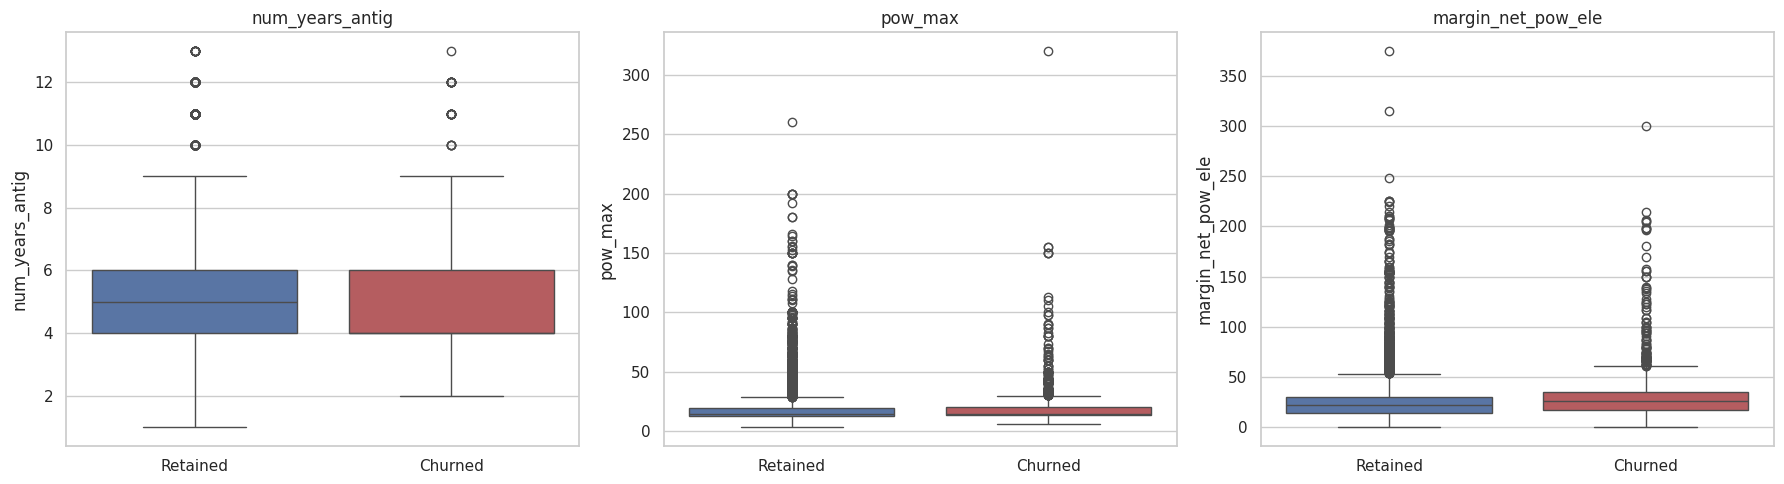

In [23]:
numeric_vs_churn_plain = ['num_years_antig', 'pow_max', 'margin_net_pow_ele']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_vs_churn_plain):
    sns.boxplot(data=client_df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


### 4.4 Correlation of numeric variables with churn

A simple point-biserial correlation (equivalent to a standard Pearson correlation against the binary
`churn` column) gives a rough, linear-only ranking of which numeric variables move together with churn.
This won't capture non-linear relationships, but it's a fast first pass.


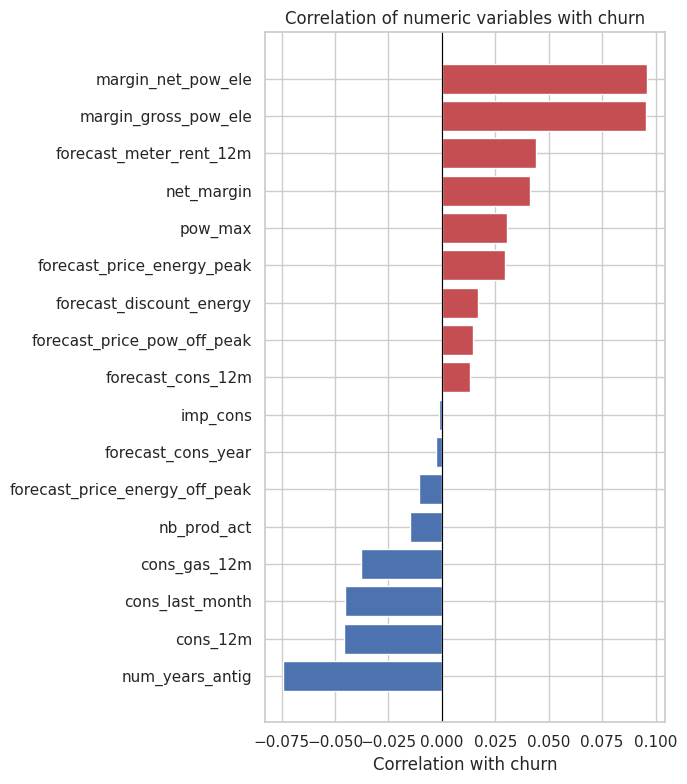

In [24]:
numeric_cols = client_df.select_dtypes(include=[np.number]).columns.drop('churn')

corr_with_churn = client_df[numeric_cols].apply(lambda x: x.corr(client_df['churn'])).sort_values()

fig, ax = plt.subplots(figsize=(7, 8))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr_with_churn.values]
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with churn')
ax.set_title('Correlation of numeric variables with churn')
plt.tight_layout()
plt.show()


**Observations — churn vs. independent variables:**
- **`has_gas`** shows almost no difference in churn rate between gas and non-gas clients — dual-fuel
  status alone doesn't look predictive
- **`channel_sales`** shows real spread: some sales channels have a noticeably higher churn rate than
  others, and the `MISSING` channel is one of the higher-churn groups — worth encoding as its own category
  rather than dropping
- **`origin_up`** (acquisition campaign) also shows meaningful variation in churn rate across codes,
  suggesting *how* a client was acquired is somewhat predictive
- **Number of active products** — churn rate is fairly flat across 1–3 products, so this alone isn't a
  strong signal in this cut
- **Numeric variables** — none of the correlations with churn are strong in absolute terms (all are
  small), which is typical for churn problems: no single variable "explains" churn, and we should expect
  a model that combines several weak signals (and probably engineered features from `price_data`) to do
  meaningfully better than any one variable here


## 5. Summary of findings

- **Data types:** most columns were read in correctly, but the four date columns in `client_data` and
  `price_date` in `price_data` needed explicit conversion to `datetime`. `churn` and `has_gas` are
  effectively booleans; `channel_sales` and `origin_up` are categorical codes (hashed for privacy)
- **Missing data:** no `NaN`s in either file, but `channel_sales` encodes missing values as the string
  `"MISSING"` rather than a true null — worth treating as "unknown channel" in later analysis
- **Target imbalance:** only ~9.7% of clients churned, so downstream modeling will need to account for
  class imbalance (e.g. stratified sampling, class weights, or resampling)
- **Skewed numeric columns:** consumption, forecast, and margin columns are all heavily right-skewed
  with a long tail of large industrial clients — log-transforms or robust scaling will likely help any
  model built on these features
- **Sparse peak/mid-peak prices:** many `price_data` columns are 0 for most rows, reflecting clients on
  simple off-peak-only tariffs rather than missing data

In addition to the type/stats/distribution findings above:
- No single categorical or numeric variable is strongly predictive of churn on its own — `channel_sales` and `origin_up` show the most visible spread in churn rate, while `has_gas` and `nb_prod_act` show little
- Numeric variables all have weak linear correlation with churn, consistent with churn being driven by a combination of factors rather than one dominant variable

**Next step:** merge `client_data` with `price_data` (e.g. average/variation of prices per client) to
start engineering features for a churn model.
